# Deliverable 3 — Pipeline & Model Analysis

Implements **POC Deliverable 3** and proposal **Metric 3 (latency)**: confidence **calibration** (reliability diagram, ECE), end-to-end **latency**, the auto-apply **threshold** trade-off, and **limitations**.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('/Users/agentilt/github/OneLPMVP/capstone')
sys.path.insert(0, str(ROOT / 'lib'))
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('capstone root:', ROOT)


capstone root: /Users/agentilt/github/OneLPMVP/capstone


## 1. Load analysis

In [2]:
res = json.load(open(ROOT/'deliverable-3-pipeline-analysis'/'results'/'pipeline_analysis.json'))
c, l = res['calibration'], res['latency']
print('ECE %.3f | mean conf %.3f vs accuracy %.3f (%+.1f pts)' % (c['ece'],c['mean_confidence'],c['mean_accuracy'],(c['mean_confidence']-c['mean_accuracy'])*100))
print('Latency P50 %.1fs (target<30) | P95 %.1fs (target<90)' % (l['p50'], l['p95']))

ECE 0.056 | mean conf 0.920 vs accuracy 0.965 (-4.5 pts)
Latency P50 23.9s (target<30) | P95 29.4s (target<90)


## 2. Reliability diagram — conservative calibration

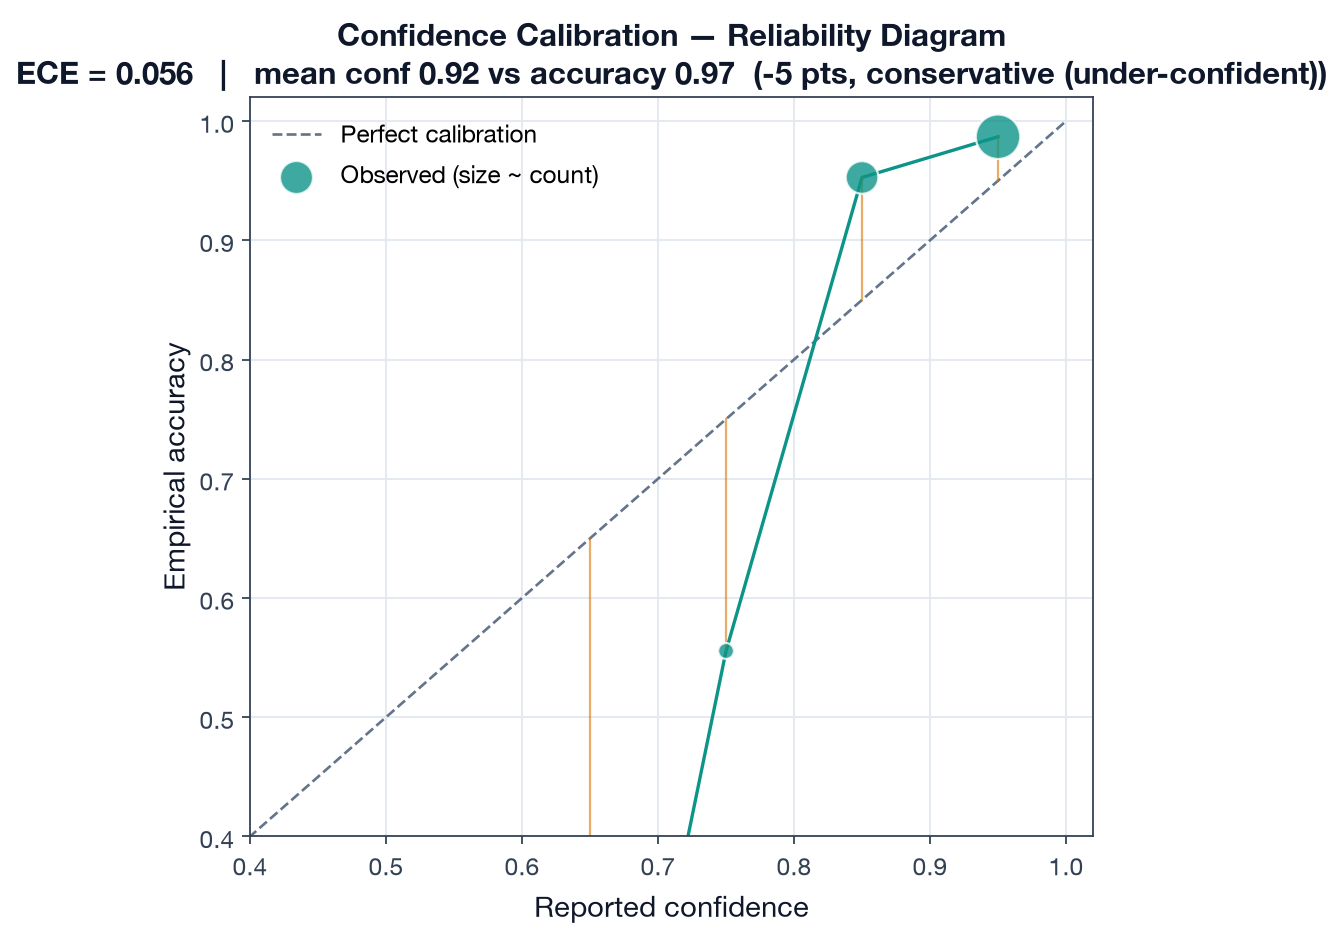

In [3]:
display(Image(str(ROOT/'deliverable-3-pipeline-analysis'/'figures'/'reliability_diagram.png')))

## 3. Calibration by field category

,mean_conf,mean_acc,overconfidence,n
date,0.914,1.000,-0.086,39.000
table,0.919,1.000,-0.081,36.000
money,0.923,0.981,-0.058,156.000
narr,0.914,0.944,-0.030,108.000
num,0.922,0.945,-0.023,110.000
enum,0.940,0.923,0.016,13.000


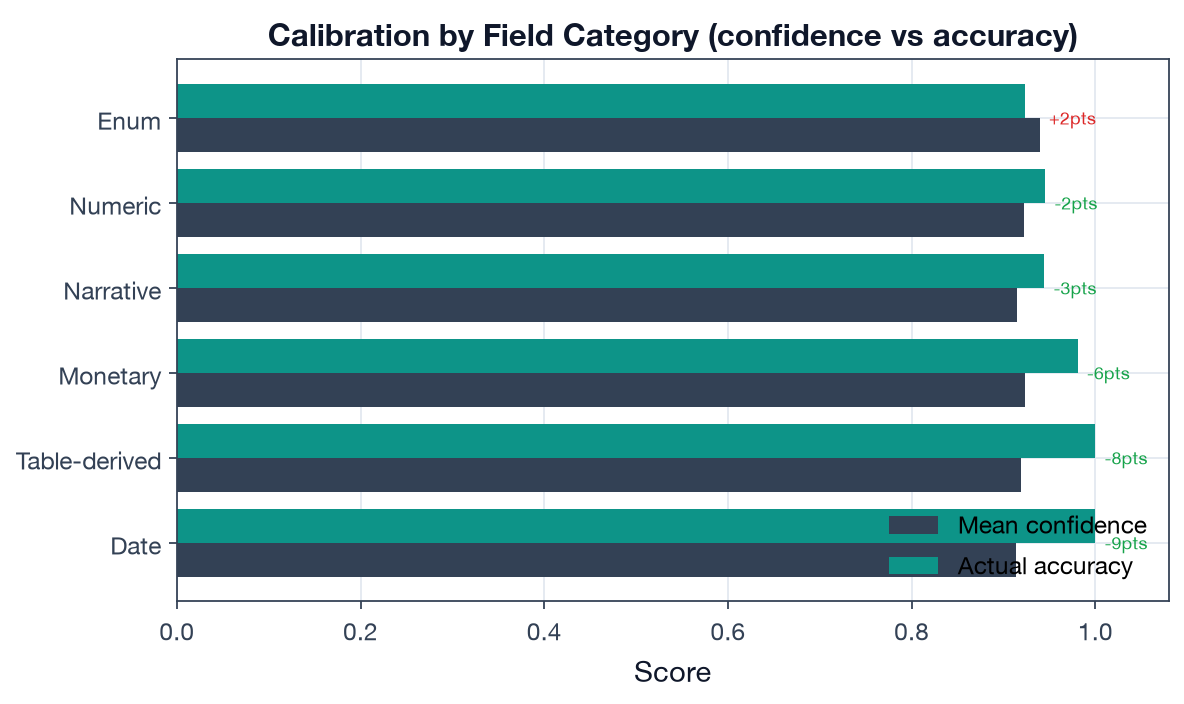

In [4]:
cc = pd.DataFrame(res['calibration']['by_category']).T.sort_values('overconfidence')
display(cc[['mean_conf','mean_acc','overconfidence','n']])
display(Image(str(ROOT/'deliverable-3-pipeline-analysis'/'figures'/'calibration_by_category.png')))

## 4. Auto-apply threshold operating curve

,threshold,auto_apply_rate,error_leakage,review_rate
4,0.700,0.998,0.033,0.002
6,0.800,0.978,0.024,0.022
7,0.850,0.896,0.019,0.104
8,0.900,0.667,0.013,0.333
9,0.950,0.331,0.026,0.669


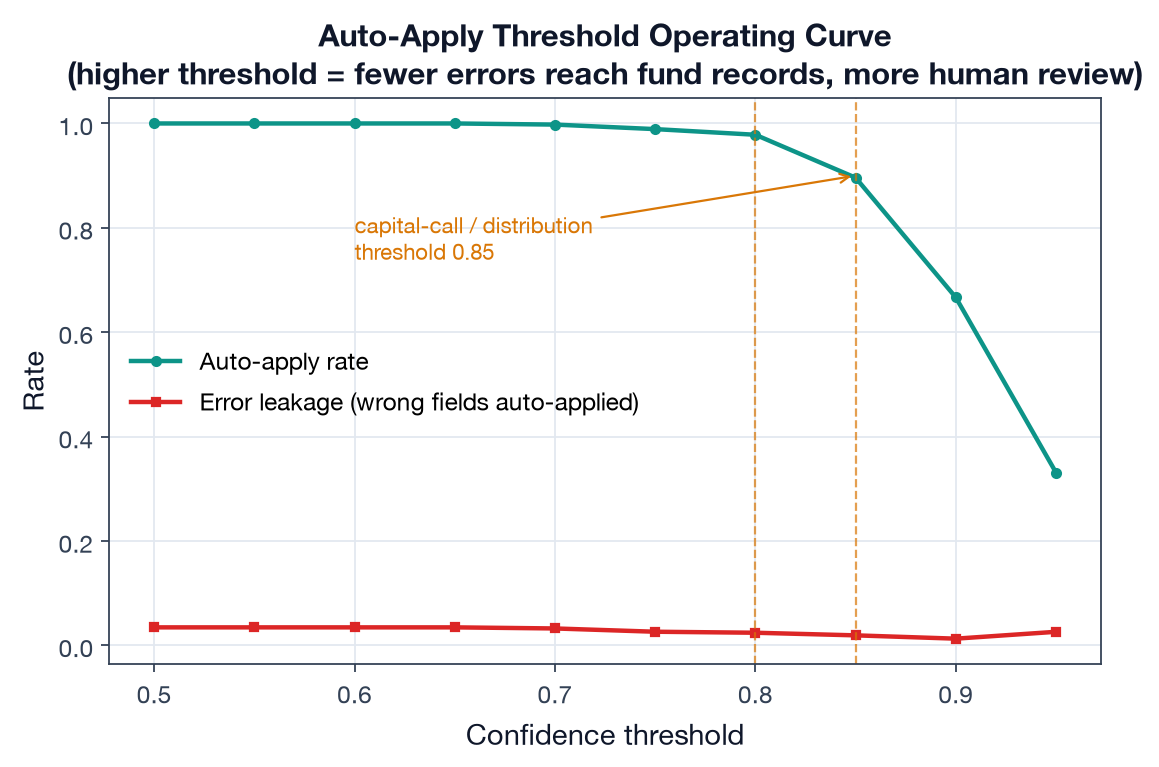

In [5]:
th = pd.DataFrame(res['threshold_operating'])
display(th[th['threshold'].isin([0.70,0.80,0.85,0.90,0.95])])
display(Image(str(ROOT/'deliverable-3-pipeline-analysis'/'figures'/'threshold_operating_curve.png')))

## 5. End-to-end latency (Metric 3)

stage means (s): {'detect': 2.2, 'extract_parallel': 18.9, 'merge': 1.3, 'validate': 0.8}


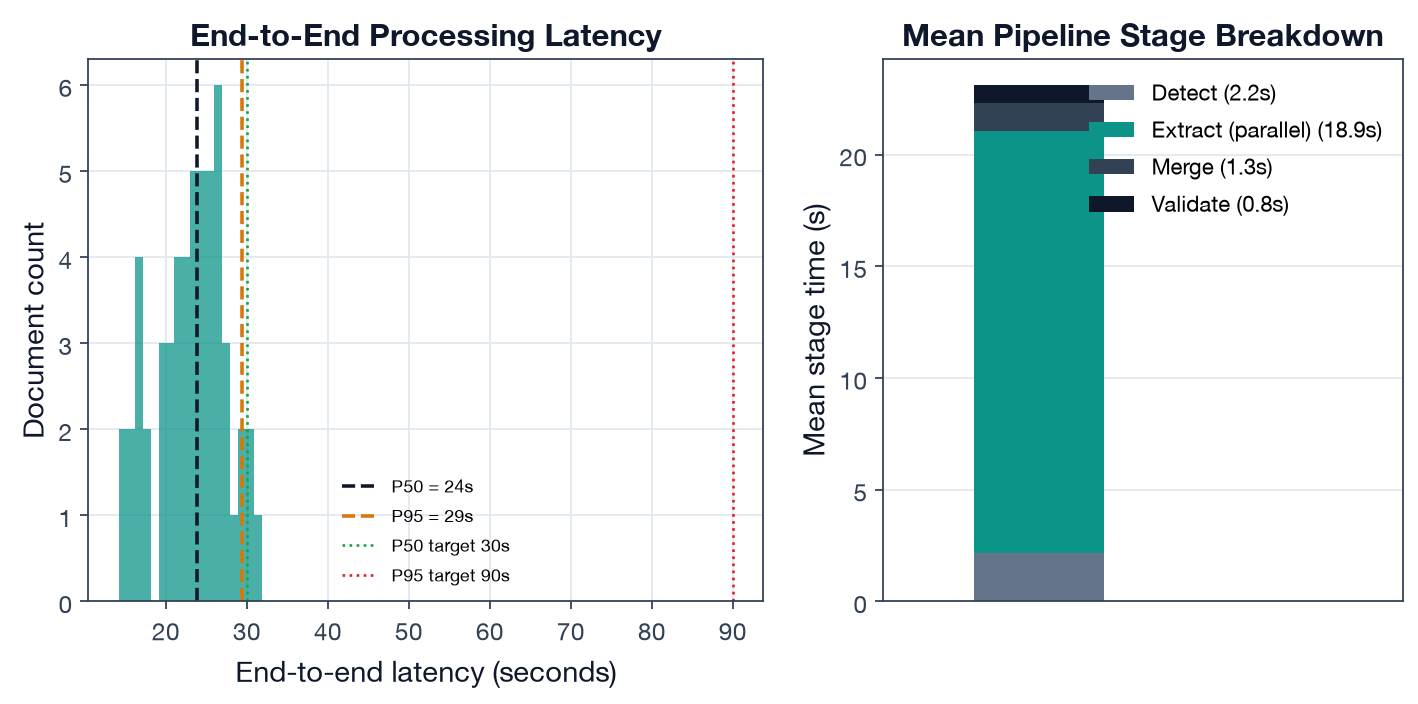

In [6]:
print('stage means (s):', {k:round(v,1) for k,v in l['stage_mean'].items()})
display(Image(str(ROOT/'deliverable-3-pipeline-analysis'/'figures'/'latency_breakdown.png')))

### Takeaway
The pipeline is conservatively calibrated (errs safe) and meets the latency targets; the opportunities are a calibration map (reclaim review capacity) and fixing the correlation-matrix fallback.